## XGBosst on the Titanic Dataset

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

In [116]:
xgb.__version__

'3.4.0'

#### Load and explore the data

In [117]:
# Load the Titanic dataset (from seaborn's built-in datasets)
df = sns.load_dataset('titanic')
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [118]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [119]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


### Feature Engineering and Preprocessing

In [120]:
# Select relevant features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
target = 'survived'

In [121]:
df_model = df[features + [target]].copy()
le = LabelEncoder()
df_model['sex'] = le.fit_transform(df_model['sex']) # female=0, male=1
df_model['embarked'] = df_model['embarked'].fillna('S') # fill 2 missing with mode
df_model['embarked'] = le.fit_transform(df_model['embarked'])
df_model['alone'] = df_model['alone'].astype(int)

# Handle missing age - note: XGBosst can handle NaN natively
# but let's fill for baseline comparison
df_model['age'] = df_model['age'].fillna(df_model['age'].median())

# Split features and target
X = df_model[features]
y = df_model[target]

print("\nClass distribution:")
print(y.value_counts(normalize=True).round(3))


Class distribution:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [122]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 712, Test size: 179


### Train the XGBoost Model

In [123]:
# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,           # Number of trees
    max_depth=4,                # Maximum depth of each tree
    learning_rate=0.1,          # Step size shrinkage (eta)
    subsample=0.8,              # Fraction of samples per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    reg_alpha=0.1,              # L1 regulatization
    reg_lambda=1.0,             # L2 Regularization
    eval_metric='logloss',
    early_stopping_rounds=20,
    enable_categorical=False,
    random_state=42
)

In [124]:
# Train the model with early stopping
eval_set = [(X_train, y_train), (X_test, y_test)]

xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=True)

print("✅ Model trained successfully")

[0]	validation_0-logloss:0.62157	validation_1-logloss:0.62874
[1]	validation_0-logloss:0.58898	validation_1-logloss:0.60183
[2]	validation_0-logloss:0.57294	validation_1-logloss:0.59549
[3]	validation_0-logloss:0.55800	validation_1-logloss:0.59052
[4]	validation_0-logloss:0.53248	validation_1-logloss:0.56809
[5]	validation_0-logloss:0.51312	validation_1-logloss:0.55333
[6]	validation_0-logloss:0.49371	validation_1-logloss:0.53800
[7]	validation_0-logloss:0.48198	validation_1-logloss:0.52955
[8]	validation_0-logloss:0.46838	validation_1-logloss:0.51874
[9]	validation_0-logloss:0.45746	validation_1-logloss:0.50906
[10]	validation_0-logloss:0.45135	validation_1-logloss:0.50654
[11]	validation_0-logloss:0.44054	validation_1-logloss:0.49869
[12]	validation_0-logloss:0.43606	validation_1-logloss:0.49875
[13]	validation_0-logloss:0.42642	validation_1-logloss:0.49270
[14]	validation_0-logloss:0.41692	validation_1-logloss:0.48691
[15]	validation_0-logloss:0.41305	validation_1-logloss:0.48608
[1

In [125]:
print("Best iteration:", xgb_model.best_iteration)
print("Best score:", xgb_model.best_score)
print("Total boosting rounds:", xgb_model.n_estimators)

Best iteration: 27
Best score: 0.4697513234432183
Total boosting rounds: 200


In [126]:
X_test.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
565,3,1,24.0,2,0,24.1500,2,0
160,3,1,44.0,0,1,16.1000,2,0
553,3,1,22.0,0,0,7.2250,0,1
860,3,1,41.0,2,0,14.1083,2,0
241,3,0,28.0,1,0,15.5000,1,0


### Evaluate Performance

In [127]:
# Predictions
y_pred = xgb_model.predict(X_test)
y_preds_proba = xgb_model.predict_proba(X_test)[:, 1]

print(y_pred)

[0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0
 1 1 0 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 0]


In [128]:
# Accuracy
train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

Training Accuracy: 0.8553 (85.53%)
Test Accuracy: 0.7989 (79.89%)

Classification Report:
              precision    recall  f1-score   support

        Died       0.79      0.92      0.85       110
    Survived       0.82      0.61      0.70        69

    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179



# Classification Report — Titanic XGBoost

Resultado obtenido:

```
              precision    recall  f1-score   support
        Died       0.79      0.92      0.85       110
    Survived       0.82      0.61      0.70        69
    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179
```

---

## `support`

Cuántos casos **reales** de cada clase hay en el test set (179 pasajeros en total).

```
110 murieron de verdad
69 sobrevivieron de verdad
110 + 69 = 179 ✓
```

---

## `recall`

Pregunta: de los casos que **realmente** son de esa clase, ¿a cuántos detectó el modelo?

**Died = 0.92**
```python
0.92 * 110 = 101  →  detectó 101 de 110 (le erró a 9)
```

**Survived = 0.61**
```python
0.61 * 69 = 42  →  detectó 42 de 69 (le erró a 27, los mandó a "murió")
```

Acá está el problema principal del modelo: **se le escapan 27 supervivientes reales**.

---

## `precision`

Pregunta inversa a recall: de todos los casos donde el modelo **predijo** esa clase, ¿cuántos acertó?

**Survived = 0.82**
```python
# El modelo dijo "sobrevivió" en total 42/0.82 ≈ 51 casos
# De esos 51, acertó en 42 (los reales)
# Se equivocó en 51-42 = 9 (dijo "sobrevivió" pero en realidad murieron)
```

> **Precision** mira "cuando el modelo dice algo, ¿tiene razón?"
> **Recall** mira "de los casos reales, ¿cuántos encontró?"
> Son preguntas distintas y pueden dar resultados muy diferentes entre sí.

---

## `f1-score`

Combina precision y recall en un solo número (media armónica, castiga si cualquiera de los dos es bajo):

```python
f1 = 2 * (precision * recall) / (precision + recall)

# Survived:
f1 = 2 * (0.82 * 0.61) / (0.82 + 0.61) = 0.70 ✓
```

---

## `accuracy`

Aciertos totales sobre el total de casos:

```python
(101 + 42) / 179 = 0.80 ✓
```
(101 aciertos en Died + 42 aciertos en Survived, sobre 179 totales)

---

## `macro avg`

Promedio simple entre las dos clases, **sin importar el support** (cada clase pesa igual, aunque tengan distinta cantidad de casos):

```python
precision_macro = (0.79 + 0.82) / 2 = 0.805 ≈ 0.81 ✓
recall_macro    = (0.92 + 0.61) / 2 = 0.765 ≈ 0.76 ✓
```

---

## `weighted avg`

Igual que macro avg, pero ponderado por `support` (la clase con más casos pesa más en el promedio):

```python
recall_weighted = (0.92*110 + 0.61*69) / 179 = 0.80 ✓
```

---

## Por qué importa macro vs weighted

Con clases desbalanceadas (61.6% Died / 38.4% Survived en este dataset):

- **`weighted avg`** se parece más a `accuracy`, porque la clase mayoritaria (Died) domina el promedio.
- **`macro avg`** muestra la realidad cruda: recall promedio de 0.76, arrastrado hacia abajo por el pobre 0.61 de Survived.

👉 **Macro avg es el que hay que mirar cuando te importan ambas clases por igual**, no solo la mayoritaria.

---

## Diagnóstico del modelo

- Detecta bien a los que murieron (recall 0.92).
- Le cuesta detectar a los que sobrevivieron (recall 0.61) — se le escapan ~40% de los supervivientes reales.
- Causa raíz: desbalance de clases en el dataset (más ejemplos de "murió" para aprender durante el entrenamiento).
- Posible siguiente paso: usar `scale_pos_weight` en XGBoost para que el modelo le dé más importancia a la clase minoritaria (Survived) durante el entrenamiento.


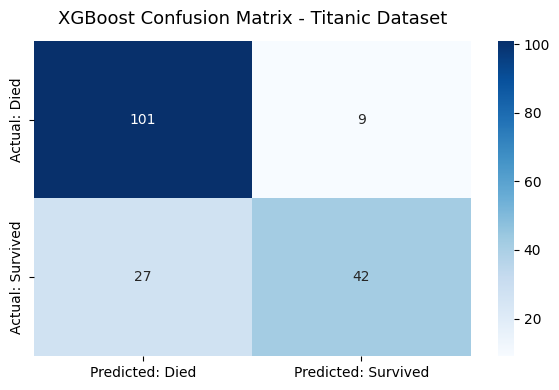

In [129]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'])
plt.title('XGBoost Confusion Matrix - Titanic Dataset', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### Feature Importance

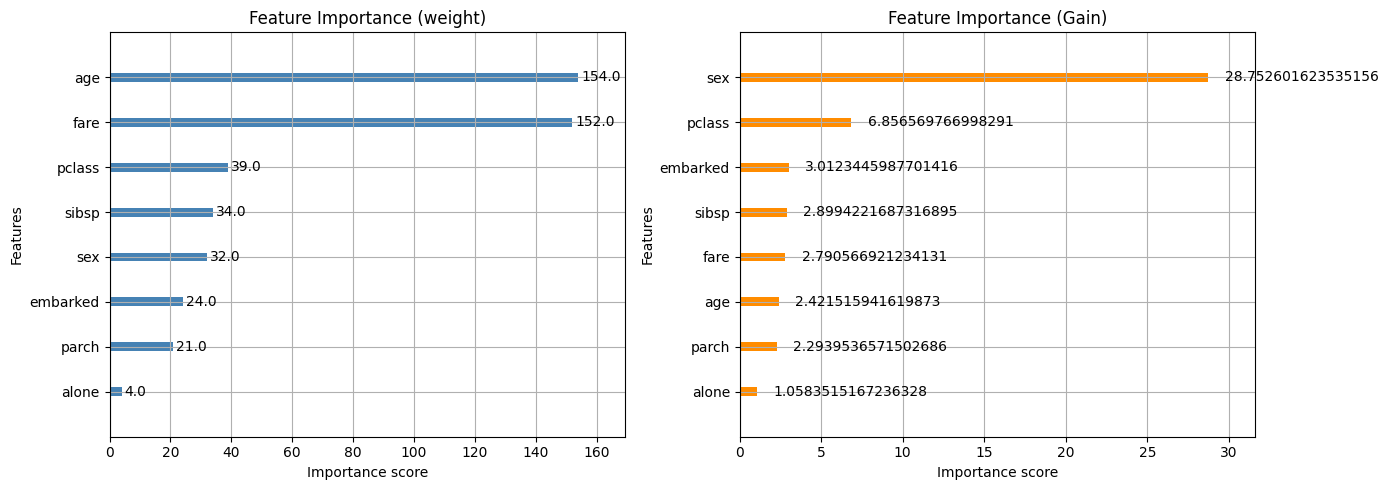

In [130]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight-based importance (number of times a featured is used)
xgb.plot_importance(xgb_model, ax=axes[0], importance_type='weight',
                    title='Feature Importance (weight)',
                    color='steelblue')

# Gain-based importance (average gain per split - more meaningful)
xgb.plot_importance(xgb_model, ax=axes[1], importance_type='gain',
                    title='Feature Importance (Gain)',
                    color='darkorange')

plt.tight_layout()
plt.show()

### SHAP Values - Understanding Why the model predicts with it does

In [131]:
# SHAP explainability
explainer = shap.TreeExplainer(xgb_model, X_train, feature_perturbation='tree_path_dependent')
shap_values = explainer(X_test)

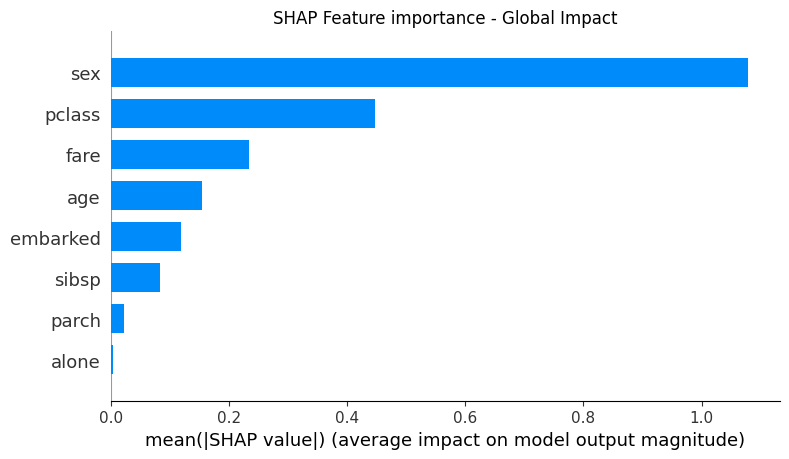

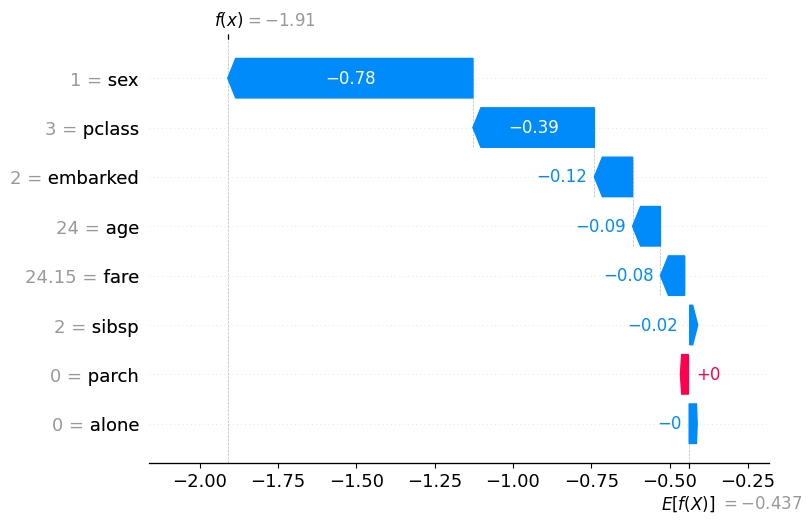

In [132]:
# Summary Plot - Shows impact of each feature on model output
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature importance - Global Impact")
plt.tight_layout()
plt.show()

# Waterfall plot for a single prediction - explain one passenger's survival prediction
print("\n\n")
shap.waterfall_plot(shap_values[0])

## Hyperparameter Tuning with GridSearchCV

In [133]:
# Tune Key hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3,4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.9]
}

In [134]:
xgb_tuned = xgb.XGBClassifier(
    eval_metric='logloss',
    enable_categorical=False,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
✅ Best CV Accuracy: 0.8245


In [135]:
# Evaluate best model
best_model = grid_search.best_estimator_
best_test_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"✅ Tuned Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")

✅ Tuned Test Accuracy: 0.7877 (78.77%)


# Conclusiones — XGBoost en Titanic

## Resumen de resultados

| Modelo | Test Accuracy | Notas |
|---|---|---|
| XGBoost (early stopping, 27 árboles) | **79.89%** | Encontrado automáticamente monitoreando logloss de test |
| XGBoost (GridSearchCV, 180 fits) | 78.77% | `learning_rate=0.2, max_depth=3, n_estimators=100, subsample=0.7` |
| GridSearch CV Accuracy (train, 5-fold) | 82.45% | No comparable directamente con test — medido en train |

---

## Hallazgo principal: más búsqueda ≠ mejor resultado

El modelo entrenado con **early stopping** (que decide solo, en tiempo real, cuándo frenar mirando el logloss del test set) superó al modelo elegido tras probar **180 combinaciones de hiperparámetros** con GridSearchCV.

**Por qué pasó esto:**

1. **`best_score_` de GridSearch mide algo distinto que test accuracy.** Es el promedio de accuracy en cross-validation sobre train (5 folds). No garantiza que esos parámetros generalicen igual de bien al test set real — con 36 combinaciones probadas, hay más chance de que una gane por azar en esa partición específica de datos, no porque sea genuinamente mejor.

2. **GridSearch no usó early stopping.** Corrió `n_estimators` fijo (100), sin poder frenar antes si el modelo empezaba a overfittear. El modelo original sí monitoreó el logloss real de test durante el entrenamiento y encontró su punto óptimo (27 árboles) de forma dinámica.

3. **Dataset chico (891 filas, test de 179).** La diferencia de 79.89% vs 78.77% son literalmente ~2 pasajeros. Con tan pocos datos, el ruido del split entra en juego — no hay que sacar conclusiones grandiosas de 1 punto porcentual de diferencia.

---

## Lección para producción / entrevistas

> Un mecanismo simple pero bien diseñado (early stopping monitoreando la métrica correcta) puede superar a una búsqueda exhaustiva de hiperparámetros mal alineada con el objetivo real. La pregunta importante no es "¿probé suficientes combinaciones?" sino "¿estoy optimizando y validando contra la métrica correcta?"

---

## Otros hallazgos del ejercicio

### Desbalance de clases
- Dataset: 61.6% murió / 38.4% sobrevivió
- Accuracy sola (80%) esconde que el **recall de "Survived" era solo 61%** — el modelo detecta mejor a los que murieron que a los que sobrevivieron
- `macro avg` (0.76 recall) es más honesto que `weighted avg` (0.80) cuando hay desbalance, porque no deja que la clase mayoritaria domine el promedio

### Feature importance: weight vs gain
- `weight` (cuántas veces se usa una feature) puede engañar: `age` y `fare` (continuas) se usan muchas veces pero cada split aporta poco
- `gain` (cuánto mejora el modelo cada vez que se usa) es más confiable: `sex` domina con gain=28.75, muy por encima del resto — confirma la intuición histórica ("mujeres y niños primero")

### SHAP: de lo global a lo individual
- Feature importance (`gain`) responde "¿qué importa en general?"
- SHAP responde "¿por qué el modelo predijo ESTO para ESTA persona?"
- Ejemplo: un pasajero con 13% de probabilidad de sobrevivir — el desglose SHAP mostró que `sex=hombre` (-0.78) y `pclass=3` (-0.39) explicaban casi toda la predicción, con edad/tarifa/familia casi sin peso

### Errores de ambiente (XGBoost 3.4.0)
- `use_label_encoder` fue eliminado del constructor — rompe si se usa
- `enable_categorical=True` puede quedar seteado por accidente y rompe la compatibilidad con SHAP (`shap.Explainer`/`TreeExplainer`) — hay que forzar `enable_categorical=False` cuando los datos ya están encodeados numéricamente

---

## Próximo paso natural

Aplicar estos mismos conceptos (early stopping, feature importance, SHAP) a un problema de **regresión** en vez de clasificación — el caso de uso real es el proyecto Yellow Taxi (predicción de demanda), donde las métricas cambian a RMSE/MAE/R² en vez de accuracy/precision/recall.

## Comparing XGBoost against other algorithms

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5,
                                            random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500,
                                              random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,
                                            random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=47, max_depth=4,
                                 learning_rate=0.1, eval_metric='logloss',
                                 random_state=42)
}

results = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  acc = accuracy_score(y_test, model.predict(X_test))
  results[name] = acc
  print(f"{name:<25} Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Decision Tree             Test Accuracy: 0.7598 (75.98%)
Logistic Regression       Test Accuracy: 0.8101 (81.01%)
Random Forest             Test Accuracy: 0.8045 (80.45%)
XGBoost                   Test Accuracy: 0.7989 (79.89%)


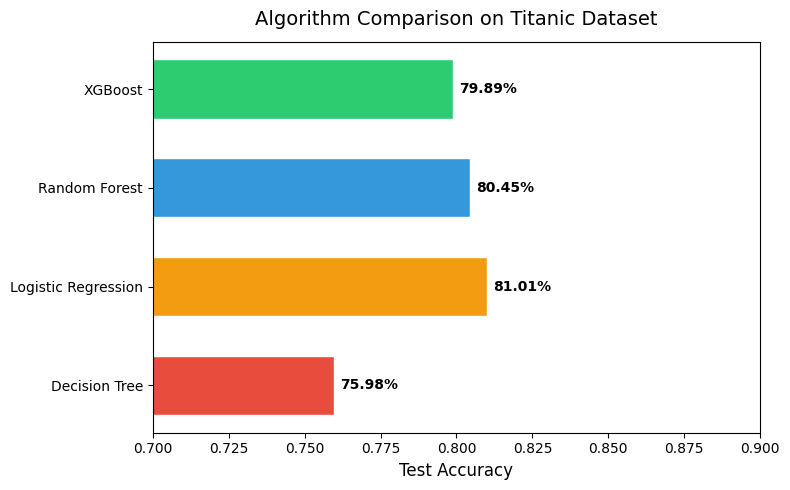

In [138]:
# Visualize comparison
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = plt.barh(list(results.keys()), list(results.values()),
                color=colors, edgecolor='white', height=0.6)
plt.xlim(0.7, 0.9)
plt.xlabel('Test Accuracy', fontsize=12)
plt.title('Algorithm Comparison on Titanic Dataset', fontsize=14, pad=12)
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc*100:.2f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()